# Context length results: latency vs input token count

Analyses the `context_test_*.csv` files produced by `tests/context_length_test.py`.

One plot: **Latency vs input token count**: mean ± SEM and p95.

In [ ]:
'''Plots context length results.'''

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
})

RESULTS_DIR = Path('..') / 'tests' / 'results'
FIGURES_DIR = Path('figures')
FIGURES_DIR.mkdir(exist_ok=True)


In [2]:
# ---------------------------------------------------------------------------
# Load the most recent context_test_*.csv file in the results directory
# ---------------------------------------------------------------------------
ctx_files = sorted(RESULTS_DIR.glob('context_test_*.csv'), reverse=True)

if not ctx_files:
    raise FileNotFoundError(
        f'No context_test_*.csv files found in {RESULTS_DIR.resolve()}. '
        'Run tests/context_length_test.py first.'
    )

raw = pd.read_csv(ctx_files[0])
print(f'Loaded: {ctx_files[0].name}')

# Keep only successful rows
data = raw[raw['error'].isna()].copy()
data['prompt_tokens'] = data['prompt_tokens'].astype(int)
data['latency_s'] = data['latency_s'].astype(float)

token_levels = sorted(data['prompt_tokens'].unique())
concurrency = data['concurrency'].iloc[0]
print(f'Prompt token levels: {token_levels}')
print(f'Concurrency: {concurrency}')
print(f'Total successful rows: {len(data)}')


Loaded: context_test_2026-04-24_13-50.csv
Prompt token levels: [np.int64(118), np.int64(240), np.int64(480), np.int64(965), np.int64(1930), np.int64(3863), np.int64(7732)]
Concurrency: 4
Total successful rows: 140


In [ ]:
# ---------------------------------------------------------------------------
# Helper: compute mean, SEM, p95 grouped by specified columns
# ---------------------------------------------------------------------------
def summarize(results, group_cols):
    """Compute mean, SEM, and p95 latency for each group.

    Parameters
    ----------
    results : pd.DataFrame
        Filtered rows of raw test data (errors already removed).
    group_cols : list[str]
        Column names to group by (e.g. ['prompt_tokens']).

    Returns
    -------
    pd.DataFrame
        One row per group with columns: mean, count, std, p95, sem.
    """
    agg = (
        results.groupby(group_cols)['latency_s']
        .agg(
            mean='mean',
            count='count',
            std='std',
            p95=lambda x: x.quantile(0.95),
        )
        .reset_index()
    )
    agg['sem'] = agg['std'] / np.sqrt(agg['count'])
    return agg


## Plot 1: latency vs input token count

Mean ± SEM (left) and p95 (right) latency as a function of input prompt length.
Concurrency is held fixed at the level used during the test run.

Saved figures/latency_vs_context_length.png


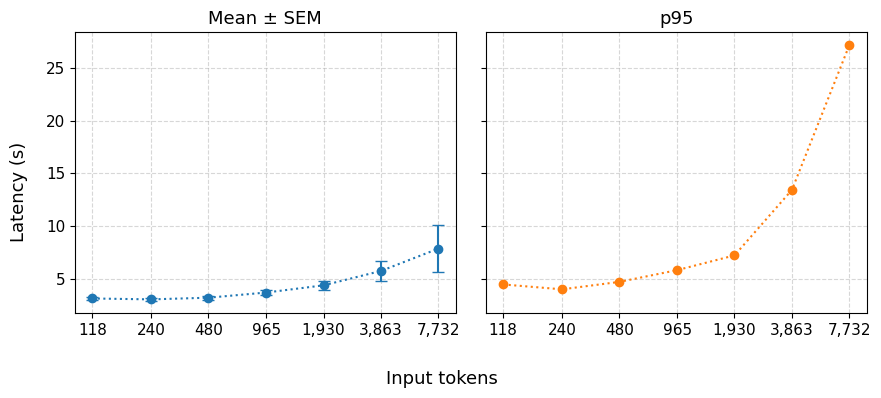

In [6]:
stats = summarize(data, ['prompt_tokens'])

tab10 = plt.get_cmap('tab10')

fig1, (ax_mean, ax_p95) = plt.subplots(1, 2, figsize=(9, 4), sharey=True)

# Mean ± SEM, left panel
ax_mean.errorbar(
    stats['prompt_tokens'], stats['mean'],
    yerr=stats['sem'],
    marker='o', markersize=6, linewidth=1.5, linestyle=':',
    capsize=4, color=tab10(0),
)
ax_mean.set_title('Mean ± SEM')

# p95, right panel
ax_p95.plot(
    stats['prompt_tokens'], stats['p95'],
    marker='o', markersize=6, linewidth=1.5, linestyle=':',
    color=tab10(1),
)
ax_p95.set_title('p95')

token_vals = stats['prompt_tokens'].tolist()

for ax in (ax_mean, ax_p95):
    ax.set_xscale('log', base=2)
    ax.set_xticks(token_vals)
    ax.set_xticklabels([f'{t:,}' for t in token_vals])
    ax.grid(True, linestyle='--', alpha=0.5)

fig1.supxlabel('Input tokens', fontsize=13)
fig1.supylabel('Latency (s)', fontsize=13)
fig1.tight_layout()

out1 = FIGURES_DIR / 'latency_vs_context_length.png'
fig1.savefig(out1, dpi=150, bbox_inches='tight')
print(f'Saved {out1}')
plt.show()
